# FinTech Project: "UKPay: A Digital Wallet System"

### Project overview
 Create a simplified version of a digital wallet system tailored to the UK market. The project will simulate essential features like peer-to-peer transfers, utility bill payments, merchant payments, and transaction tracking. Students will work on SQL for database design and querying, Python for analytics and backend logic, and visualization tools like Power BI/Tableau for insights and reporting.


#### Phase 1: Database design and SQL implementation
Objective: Design a relational database to store transaction details, user profiles, and services.
Steps:

1.	Define tables for:

o	Users: UserID, Name, Email, Phone, Balance, RegistrationDate.

o	Transactions: TransactionID, UserID, RecipientID, Amount, Type (P2P, Utility, Merchant), Date.

o	Merchants: MerchantID, MerchantName, Category, Location.

o	UtilityPayments: PaymentID, UserID, UtilityType (Electricity, Gas, Water), Amount, Date.

2.	Populate the database with a CSV containing 2000+ rows of mock data for all tables.

3.	Write SQL queries to:

o	Retrieve monthly transaction summaries for each user.

o	Identify top-performing merchants based on transaction volume.

o	Calculate the average utility bill amount per user.


## Phase 1: 
Database & SQL is completed in Mysql, I can now move to Phase 2: Python Analytics

### Phase 2: Python Analytics


Objective: Analyze transaction data for user insights and backend functionality.

#### Steps:
1.	Load data from the database into Python using libraries like pandas and sqlalchemy.

2.	Perform analytics:

o	Identify the most frequent transaction type for each user.

o	Calculate the growth in total transactions month-over-month.

o	Create user segmentation based on transaction frequency and average transaction size.

3.	Simulate backend logic:

o	Deduct balances for successful transactions.

o	Generate reminders for users with low balances.

o	Provide insights into spending patterns using Python visualizations (matplotlib, seaborn).


- The goal here is to analyze transactions and user behavior, plus simulate backend logic like balance deduction and reminders. We’ll use Python (pandas, SQLAlchemy, matplotlib/seaborn).

### Step 2a: Connect Python to MySQL and load data

In [13]:
!pip install pandas sqlalchemy mysql-connector-python matplotlib seaborn

- Load tables into pandas:

In [15]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to MySQL (no password)
engine = create_engine('mysql+mysqlconnector://root:@localhost/ukpay_db')

# Load data into pandas
users = pd.read_sql("SELECT * FROM Users", con=engine)
merchants = pd.read_sql("SELECT * FROM Merchants", con=engine)
transactions = pd.read_sql("SELECT * FROM Transactions", con=engine)
utility_payments = pd.read_sql("SELECT * FROM UtilityPayments", con=engine)

# Quick check
print("Users:", users.shape)
print("Merchants:", merchants.shape)
print("Transactions:", transactions.shape)
print("UtilityPayments:", utility_payments.shape)

Users: (500, 6)
Merchants: (20, 4)
Transactions: (2000, 7)
UtilityPayments: (2000, 5)


### Step 2b: Analytics tasks

I’ll tackle one at a time, as per project requirements:

1. Identify the most frequent transaction type per user

2. Calculate month-over-month transaction growth

3. Create user segmentation based on transaction frequency and average transaction size

4. Simulate backend logic:

- Deduct balances for successful transactions

- Generate low balance reminders

- Visualize spending patterns

#### Task 1: Most frequent transaction type per user.

In [16]:
# Most frequent transaction type per user
freq_type = transactions.groupby(['UserID','Type']).size().reset_index(name='Count')
most_freq = freq_type.loc[freq_type.groupby('UserID')['Count'].idxmax()]

print(most_freq.head())

   UserID      Type  Count
0       1  Merchant      3
3       2   Utility      1
4       3  Merchant      5
5       4       P2P      2
7       5       P2P      3


#### Step 2b-Task 2: Month-over-Month transaction growth

   YearMonth  TotalTransactions  MoM_Growth
0    2024-01                 89    0.000000
1    2024-02                138   55.056180
2    2024-03                174   26.086957
3    2024-04                158   -9.195402
4    2024-05                186   17.721519
5    2024-06                174   -6.451613
6    2024-07                181    4.022989
7    2024-08                155  -14.364641
8    2024-09                165    6.451613
9    2024-10                186   12.727273
10   2024-11                153  -17.741935
11   2024-12                160    4.575163
12   2025-01                 76  -52.500000
13   2025-04                  1  -98.684211
14   2025-06                  2  100.000000
15   2025-08                  1  -50.000000
16   2025-12                  1    0.000000


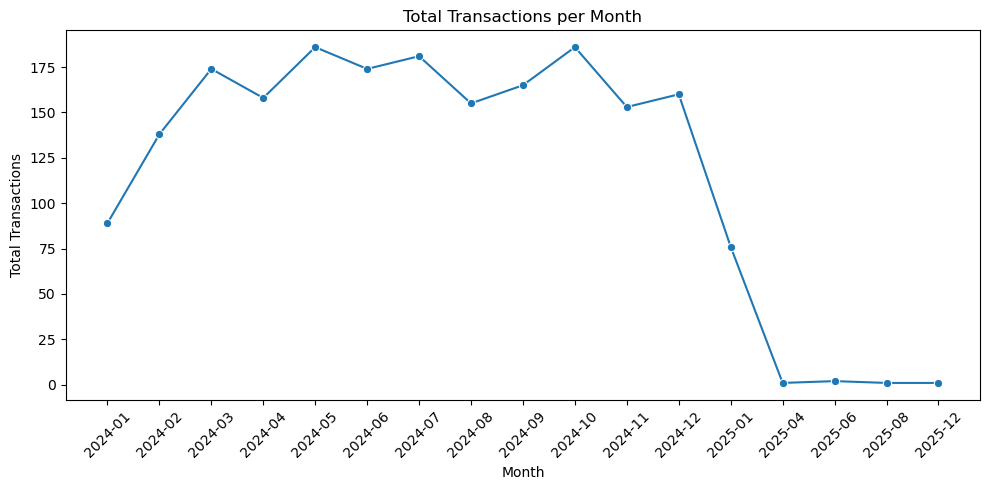

In [18]:
# Phase 2 - Task 2: Month-over-Month Transaction Growth

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Connect to MySQL
engine = create_engine('mysql+mysqlconnector://root:@localhost/ukpay_db')

# Load Transactions table
transactions = pd.read_sql("SELECT * FROM Transactions", con=engine)

# Ensure 'Date' column is datetime
transactions['Date'] = pd.to_datetime(transactions['Date'], errors='coerce')
transactions = transactions.dropna(subset=['Date'])  # remove invalid dates

# Create Year-Month column as string for grouping
transactions['YearMonth'] = transactions['Date'].dt.strftime('%Y-%m')

# Group by YearMonth and count total transactions
monthly_counts = transactions.groupby('YearMonth').size().reset_index(name='TotalTransactions')

# Calculate Month-over-Month (MoM) growth %
monthly_counts['MoM_Growth'] = monthly_counts['TotalTransactions'].pct_change() * 100
monthly_counts['MoM_Growth'] = monthly_counts['MoM_Growth'].fillna(0)

# Display table
print(monthly_counts)

# Plot total transactions per month
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_counts, x='YearMonth', y='TotalTransactions', marker='o')
plt.xticks(rotation=45)
plt.title("Total Transactions per Month")
plt.ylabel("Total Transactions")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

#### Step 3: User segmentation

   UserID  TransactionCount  AvgTransactionAmount FrequencySegment  \
0       1                 7            415.901429        Very High   
1       2                 1            191.750000              Low   
2       3                 5            505.932000             High   
3       4                 3            237.740000              Low   
4       5                 3            215.390000              Low   
5       6                 1            330.160000              Low   
6       7                 4            334.677500           Medium   
7       8                 2            765.840000              Low   
8       9                 4            426.322500           Medium   
9      10                 4            156.515000           Medium   

  AmountSegment                Segment  
0     Very High  Very High | Very High  
1        Medium           Low | Medium  
2     Very High       High | Very High  
3        Medium           Low | Medium  
4        Medium         

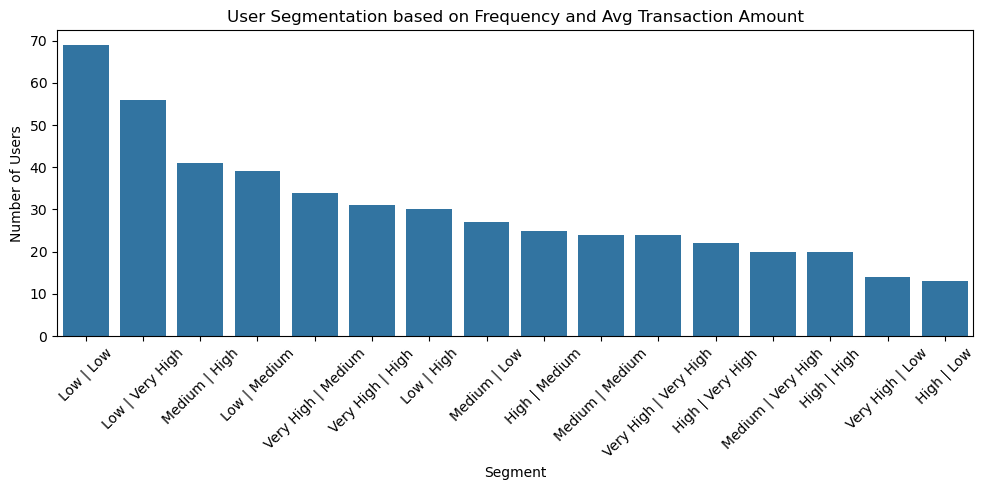

In [19]:
import pandas as pd
from sqlalchemy import create_engine

# Connect to MySQL
engine = create_engine('mysql+mysqlconnector://root:@localhost/ukpay_db')

# Load Transactions table
transactions = pd.read_sql("SELECT * FROM Transactions", con=engine)

# Ensure Date is datetime
transactions['Date'] = pd.to_datetime(transactions['Date'], errors='coerce')
transactions = transactions.dropna(subset=['Date'])

# Step 1: Compute transaction frequency and average transaction amount per user
user_stats = transactions.groupby('UserID').agg(
    TransactionCount=('TransactionID', 'count'),
    AvgTransactionAmount=('Amount', 'mean')
).reset_index()

# Step 2: Define segmentation based on quartiles
user_stats['FrequencySegment'] = pd.qcut(user_stats['TransactionCount'], 4, labels=['Low','Medium','High','Very High'])
user_stats['AmountSegment'] = pd.qcut(user_stats['AvgTransactionAmount'], 4, labels=['Low','Medium','High','Very High'])

# Step 3: Combine segments
user_stats['Segment'] = user_stats['FrequencySegment'].astype(str) + " | " + user_stats['AmountSegment'].astype(str)

# Display top 10 users with segments
print(user_stats.head(10))

# Optional: visualize distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x='Segment', data=user_stats, order=user_stats['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title("User Segmentation based on Frequency and Avg Transaction Amount")
plt.ylabel("Number of Users")
plt.xlabel("Segment")
plt.tight_layout()
plt.show()

####  What this code does

1. Groups transactions by UserID to calculate:

- Total number of transactions (TransactionCount)

- Average transaction amount (AvgTransactionAmount)

2. Creates quartile-based segments for:

- Transaction frequency (FrequencySegment)

- Average transaction amount (AmountSegment)

3. Combines them into a final segment label like: "High | Medium"

4. Prints the top 10 users and visualizes the distribution of segments.

#### Step 4: Backend logic simulation

Users with low balance reminders:
Reminder: User Abigail Shaffer (ID: 2) has a low balance of £25.01. Please top up.
Reminder: User Juan Calderon (ID: 3) has a low balance of £41.03. Please top up.
Reminder: User Nicholas Nunez (ID: 10) has a low balance of £29.80. Please top up.
Reminder: User Bradley Sandoval (ID: 13) has a low balance of £26.54. Please top up.
Reminder: User Michelle Harris (ID: 15) has a low balance of £6.75. Please top up.
Reminder: User Evelyn Galvan (ID: 17) has a low balance of £-48.37. Please top up.
Reminder: User Elizabeth Clark (ID: 20) has a low balance of £6.50. Please top up.
Reminder: User Stephanie Salazar (ID: 22) has a low balance of £24.89. Please top up.
Reminder: User Angela Hernandez (ID: 23) has a low balance of £31.64. Please top up.
Reminder: User Steven Houston (ID: 24) has a low balance of £23.49. Please top up.
Reminder: User Tracy Jones (ID: 42) has a low balance of £45.82. Please top up.
Reminder: User Ian Phillips (ID: 45) has a low bala

C:\Users\ASUS-PC\AppData\Local\Temp\ipykernel_9168\1919723615.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_spending, x='Type', y='Amount', palette='viridis')


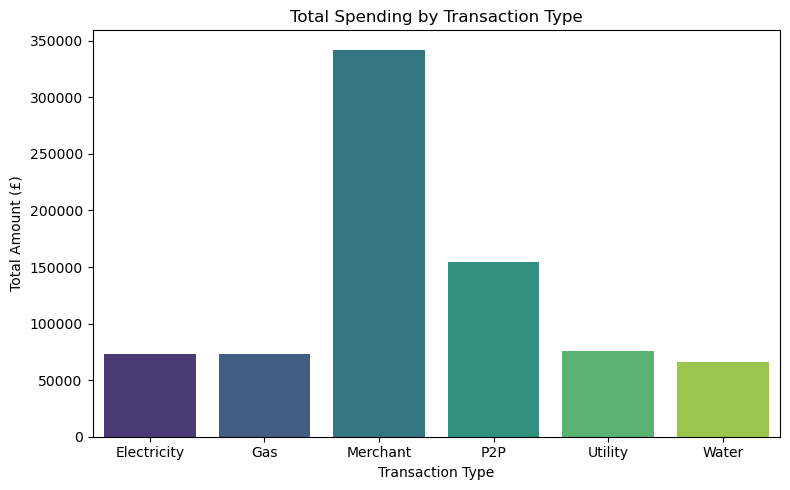

C:\Users\ASUS-PC\AppData\Local\Temp\ipykernel_9168\1919723615.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_users_sum, x='UserID', y='Amount', palette='magma')


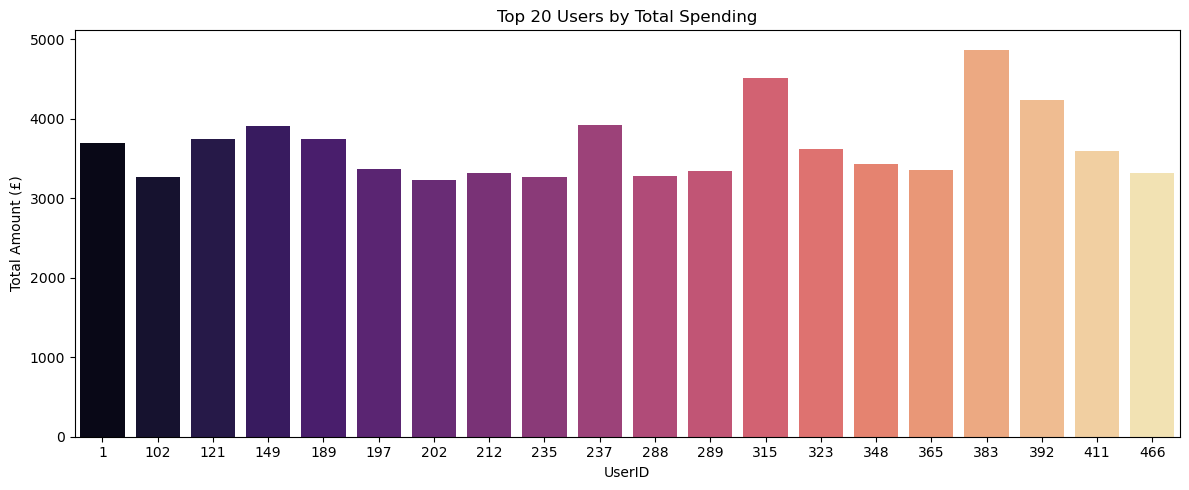

In [21]:
# Phase 2 Task 4: Backend Logic + Insights

import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to MySQL
engine = create_engine('mysql+mysqlconnector://root:@localhost/ukpay_db')

# Load tables
users = pd.read_sql("SELECT * FROM Users", con=engine)
transactions = pd.read_sql("SELECT * FROM Transactions", con=engine)
utility_payments = pd.read_sql("SELECT * FROM UtilityPayments", con=engine)

# Ensure numeric columns
transactions['Amount'] = pd.to_numeric(transactions['Amount'], errors='coerce')
utility_payments['Amount'] = pd.to_numeric(utility_payments['Amount'], errors='coerce')
users['Balance'] = pd.to_numeric(users['Balance'], errors='coerce')

# -------------------------------
# Step 1: Deduct balances for transactions
# -------------------------------
def process_transaction(row, users_df):
    user_id = row['UserID']
    amount = row['Amount']
    balance = users_df.loc[users_df['UserID']==user_id, 'Balance'].values[0]
    
    if balance >= amount:
        users_df.loc[users_df['UserID']==user_id, 'Balance'] -= amount
        return True  # Transaction successful
    else:
        return False  # Insufficient balance

transactions['Success'] = transactions.apply(lambda x: process_transaction(x, users), axis=1)

# -------------------------------
# Step 2: Generate low balance reminders
# -------------------------------
threshold = 50  # GBP
low_balance_users = users[users['Balance'] < threshold][['UserID', 'Name', 'Balance']]
print("Users with low balance reminders:")
for idx, row in low_balance_users.iterrows():
    print(f"Reminder: User {row['Name']} (ID: {row['UserID']}) has a low balance of £{row['Balance']:.2f}. Please top up.")

# -------------------------------
# Step 3: Spending pattern insights
# -------------------------------
# Combine all transactions
all_transactions = pd.concat([
    transactions[['UserID','Type','Amount']],
    utility_payments.rename(columns={'UtilityType':'Type'})[['UserID','Type','Amount']]
])

# Total spent per transaction type
type_spending = all_transactions.groupby('Type')['Amount'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=type_spending, x='Type', y='Amount', palette='viridis')
plt.title("Total Spending by Transaction Type")
plt.ylabel("Total Amount (£)")
plt.xlabel("Transaction Type")
plt.tight_layout()
plt.show()

# Top 20 users by total spending
top_users = all_transactions.groupby('UserID')['Amount'].sum().nlargest(20).index
top_users_spending = all_transactions[all_transactions['UserID'].isin(top_users)]
top_users_sum = top_users_spending.groupby('UserID')['Amount'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=top_users_sum, x='UserID', y='Amount', palette='magma')
plt.title("Top 20 Users by Total Spending")
plt.ylabel("Total Amount (£)")
plt.xlabel("UserID")
plt.tight_layout()
plt.show()

#### What this code does

1. Deduct balances for transactions that the user can afford.

2. Print low balance reminders for users below £50.

3. Analyze spending patterns across all transaction types.

4. Visualize total spending by type and top 20 users’ spending.

#### Phase 3: Data Visualization in Power BI using these Python results.